In [1]:
%load_ext autoreload
%autoreload 2

import rootutils
rootutils.setup_root('.', dotenv=True, pythonpath=True, cwd=False)

PosixPath('/home/milton/workspace/ocdm')

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from pathlib import Path

import numpy as np
import torch
import plotly.express as px
import plotly.graph_objects as go
import umap
from sklearn.neighbors import NearestNeighbors
from plotly.subplots import make_subplots
from torchvision.utils import make_grid

from src.model.autoencoder import BetaVAE, WassersteinMMDAE
from src.model.grouping import SlotAutoencoder, FigureGroundAutoencoder
from src.dataset.dsprites import DSprites
from src.dataset.shapes3d import Shapes3D
from src.dataset.pentominos import Pentominos
from src.dataset.utils import build_filter
from src.analysis.viz import strip

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [3]:
_filter = build_filter(DSprites, "( shape == 3 ) & ( posX < 0.50 )")
dsprite_train = DSprites("../data/datasets/dsprites/dsprites_train.hdf5", data_filter=lambda x: ~_filter(x))
gen_factor = dsprite_train.factor_values
len(dsprite_train)

614400

In [28]:
dataset = 
model = 'sa1'

paths = {
    'vae': "../data/results/figure1/combgen_dsprites_heart_position_vae_on:2025-11-12_13-45/embeddings.npz",
    'wae': "../data/results/figure1/combgen_dsprites_heart_position_wae_on:2025-11-20_09-21/embeddings.npz",
    'sa1': "../data/results/figure1/combgen_dsprites_heart_position_sa_on:2025-11-19_19-16/embeddings.npz",
}

emb_path = paths[model]
train_z = np.load(emb_path)['train_embeddings'].squeeze()
print(train_z.shape)

(614400, 64)


In [29]:
from sklearn.decomposition import PCA

pca = PCA()
proj = pca.fit_transform(train_z)

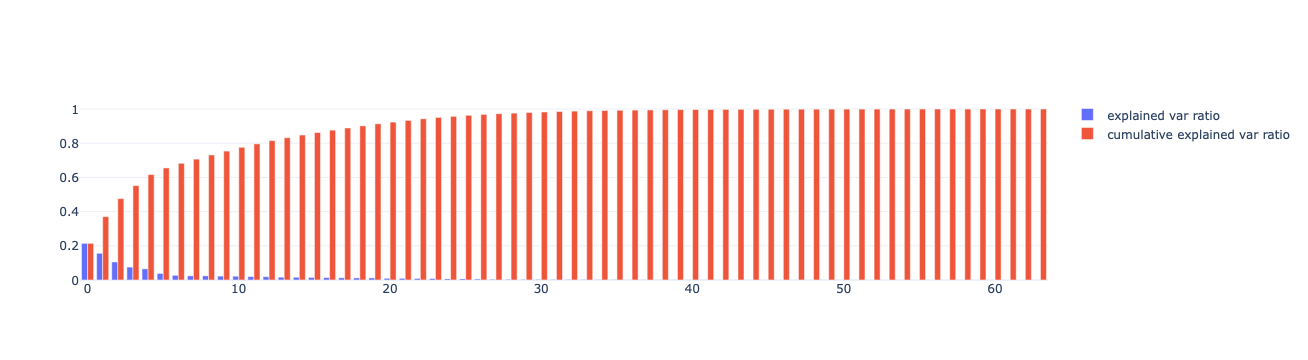

In [30]:
fig = make_subplots(rows=1, cols=1)

# Top left
fig.add_trace(
    go.Bar(y=pca.explained_variance_ratio_ , name="explained var ratio"),
    row=1, col=1
)

fig.add_trace(
    go.Bar(y=np.cumsum(pca.explained_variance_ratio_), name="cumulative explained var ratio"),
    row=1, col=1
)
fig.update_layout(template='plotly_white')
fig.write_image(f"../plots/{model}-dsprites-explained-var.png")
fig

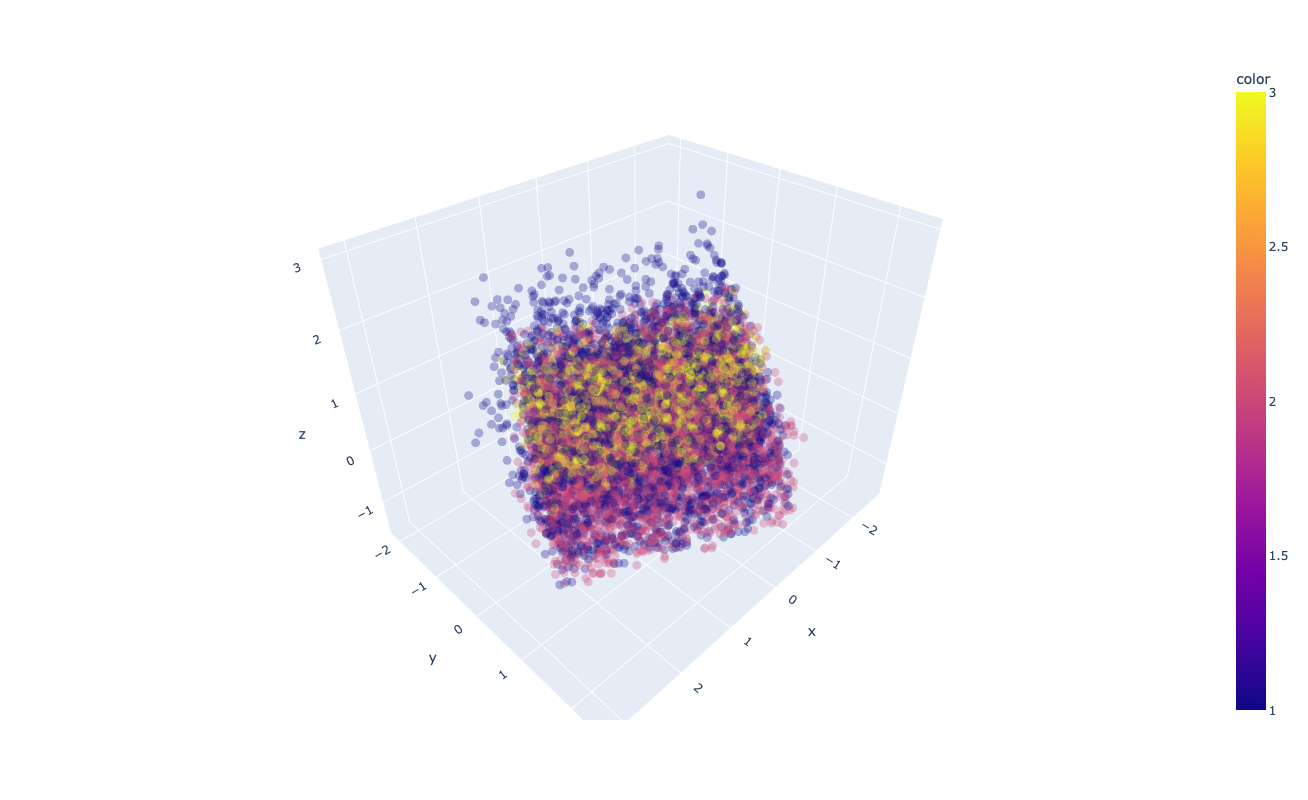

In [31]:
i = 1
# x, y = proj.T[i:i+2]
idx = np.random.choice(a=len(train_z), size=(10_000,), replace=False)
x, y, z = proj[idx].T[[0, 1, 2]]
color = gen_factor[idx, 0]

fig = px.scatter_3d(x=x, y=y, z=z, color=color, size_max=0.1, opacity=0.3, height=800, width=800)
fig.update_traces(marker=dict(size=5,), selector=dict(mode='markers'))
fig.write_html(f"../plots/{model}-dsprites-pca.html")
fig

# UMAP

In [32]:
reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, metric='euclidean')
proj = reducer.fit_transform(train_z)

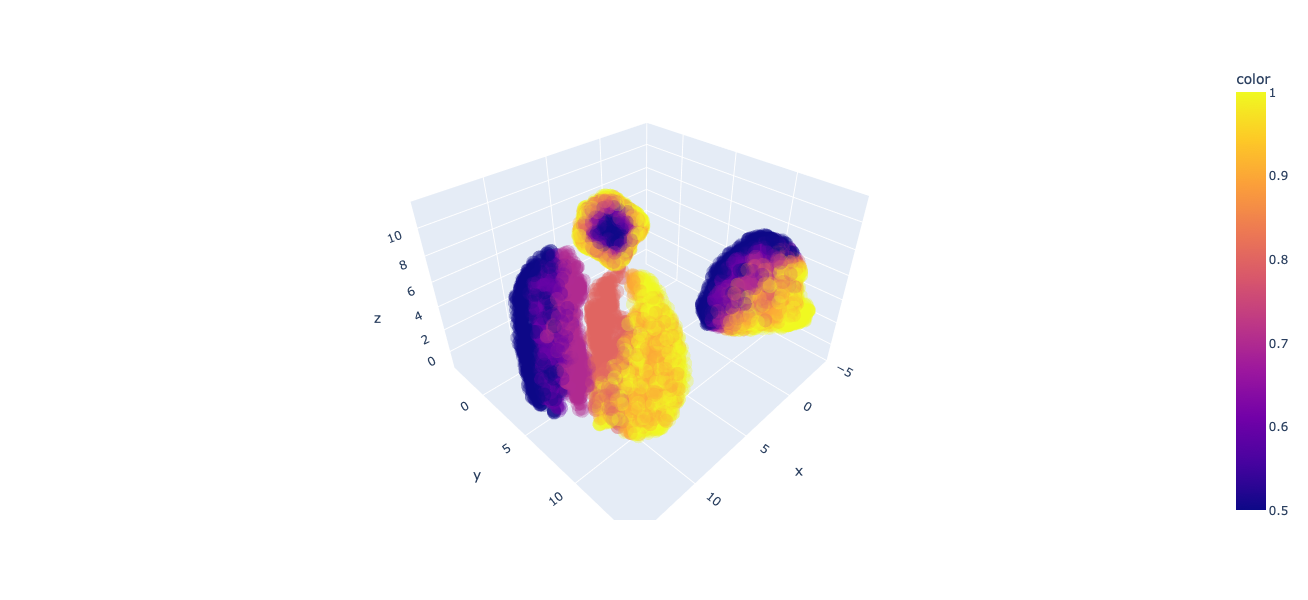

In [40]:
x, y, z = proj[idx[:10000]].T

color = gen_factor[idx[:10000], 1]

fig = px.scatter_3d(x=x, y=y, z=z,color=color, size_max=0.1, opacity=0.3, height=600, width=800)
fig.write_html(f"../plots/{model}-dsprites-train_embeddings-shaded-by-scale.html")
fig

## Testing UMPA consistency

In [10]:
from sklearn.manifold import trustworthiness

def bootstrap_score(f, x, z, n=10):
    scores = []
    for _ in range(n):
        idx = np.random.choice(a=len(x), size=(10000,), replace=False)
        scores.append(f(x[idx], z[idx], n_neighbors=15))
    return np.mean(scores), np.var(scores)

T, T_var = bootstrap_score(trustworthiness, train_z, proj)
C, C_var = bootstrap_score(trustworthiness, proj, train_z)

print(T, T_var)
print(C, C_var)

0.9078312270221509 2.2293434015702334e-06
0.9378958458454447 6.905608040959559e-07


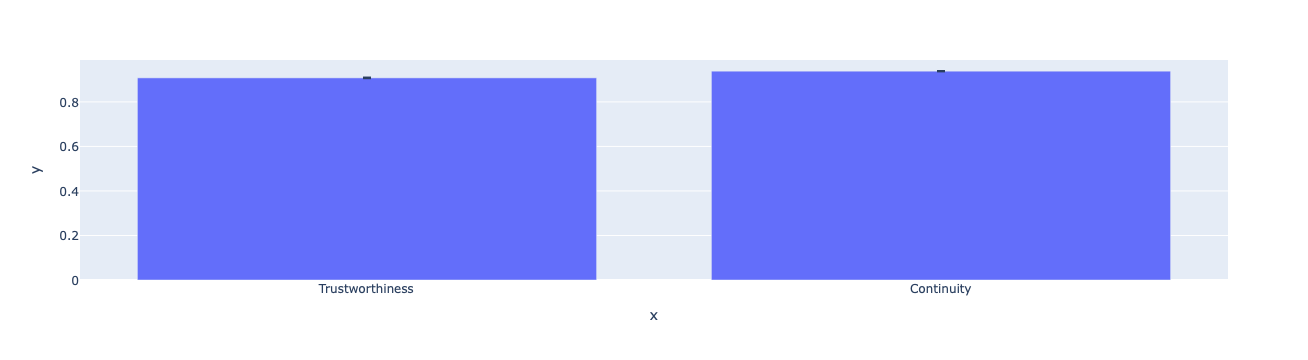

In [11]:
px.bar(x=["Trustworthiness", "Continuity"], y=[T, C], error_y=[np.sqrt(T_var), np.sqrt(C_var)])

In [49]:
def knn_overlap(x, proj, k=5):
    nnX = NearestNeighbors(n_neighbors=k).fit(x).kneighbors(return_distance=False)
    nnZ = NearestNeighbors(n_neighbors=k).fit(proj).kneighbors(return_distance=False)
    return np.mean([len(set(nnX[i]).intersection(nnZ[i])) / k for i in range(len(x))])

ko = knn_overlap(train_z, proj)

In [50]:
print(ko)

0.2805592447916666


# Latent prediction

In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RepeatedKFold

heart_idx = gen_factor[:, 0] == 3
heart_z = train_z[heart_idx]
heart_g = gen_factor[heart_idx]

factor_idx = 4

for train_idx, test_idx in RepeatedKFold(n_repeats=10, n_splits=5).split(heart_z):
    x, y = heart_z[train_idx], heart_g[train_idx, factor_idx]
    x_test, y_test = heart_z[test_idx], heart_g[test_idx, factor_idx]
    linear = LinearRegression().fit(x,y)
    score = linear.score(x_test, y_test)
    print(score)

0.9908298567447417
0.9909134734452235
0.9908266845439676
0.9907927724071002
0.9907668974017712
0.9907466485193069
0.990994973344075
0.990779866198859
0.9907319916185647
0.9908864883165177
0.9908456723553262
0.990871700143436
0.9908530828837934
0.9907653235932562
0.9907953236249918
0.9907554576832165
0.9908338936279415
0.9907611433659078
0.9909108622312295
0.9908736246687104
0.9908801559688782
0.9908254908329124
0.9908026273066555
0.9907680741388367
0.9908646223729679
0.9909022412303157
0.9908483162716137
0.9909369663640881
0.9906879913910399
0.9907584891381966
0.9907831794962881
0.9907241274623371
0.9909263923173677
0.9908834060217855
0.9908159594368072
0.9908178438329555
0.9907659819842748
0.9907976719671568
0.9907836770411692
0.9909725725369453
0.9908422329005174
0.9908739741796705
0.9908926851284551
0.990699402088738
0.9908241754873409
0.9908719449045288
0.9907980836536892
0.9909173630868735
0.9907362936330373
0.9908080271776247
